# Lecture 4 – Data 100, Spring 2026

[Acknowledgments Page](https://ds100.org/sp26/acks/)

A demonstration of advanced `Polars` syntax to accompany Lecture 4.

In [1]:
import numpy as np
import polars as pl

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import plotly.express as px

## Loading Datasets: `babynames`  for California, `elections`

In [2]:
elections = pl.read_csv('data/elections.csv')
elections

Year,Candidate,Party,Popular vote,Result,%
i64,str,str,i64,str,f64
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789
…,…,…,…,…,…
2024,"""Donald Trump""","""Republican""",77303568,"""win""",49.808629
2024,"""Kamala Harris""","""Democratic""",75019230,"""loss""",48.336772
2024,"""Jill Stein""","""Green""",861155,"""loss""",0.554864


In [3]:
import urllib.request
import os.path
import zipfile

data_url = "https://www.ssa.gov/oact/babynames/state/namesbystate.zip"
local_filename = "data/babynamesbystate.zip"
if not os.path.exists(local_filename): # If the data exists don't download again
    with urllib.request.urlopen(data_url) as resp, open(local_filename, 'wb') as f:
        f.write(resp.read())

zf = zipfile.ZipFile(local_filename, 'r')

ca_name = 'STATE.CA.TXT'
field_names = ['State', 'Sex', 'Year', 'Name', 'Count']
with zf.open(ca_name) as fh:
    babynames = pl.read_csv(fh, has_header=False, new_columns=field_names)

babynames.sample(10)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1975,"""Eve""",14
"""CA""","""F""",2017,"""Zoelle""",6
"""CA""","""M""",1950,"""Junior""",9
"""CA""","""M""",1941,"""Tomas""",12
"""CA""","""M""",1961,"""Sven""",5
"""CA""","""M""",1936,"""Barry""",51
"""CA""","""M""",2001,"""Faris""",7
"""CA""","""F""",2017,"""Lyric""",76
"""CA""","""M""",2016,"""Eddie""",83


## Grouping

Group rows that share a common feature, then aggregate data across the group.

In this example, we count the total number of babies born each year in California.

In [4]:
babynames.group_by("Year")

In [5]:
# Grouping by "Year" and aggregating the "Count" column
# to get the total number of babies born each year.
# The years come back in whatever order the groups finished in, so we sort them for the plot below.
babies_by_year = babynames.group_by("Year").agg(pl.col("Count").sum()).sort("Year")
babies_by_year

Year,Count
i64,i64
1910,9163
1911,9983
1912,17946
1913,22094
1914,26926
…,…
2018,395436
2019,386996
2020,362882


In [6]:
# Plotting baby counts per year
# Don't worry about the syntax here. We will cover visualization later in the course.
fig = px.line(babies_by_year, x="Year", y="Count")
fig.update_layout(font_size=18,
                  autosize=False,
                  width=700,
                  height=400)

In [7]:
elections = elections.with_columns(win_binary = pl.col('Result') == 'win')
wins_by_party = elections.group_by("Party").agg(pl.col("win_binary").sum())
wins_by_party.sort('win_binary').tail(5)

Party,win_binary
str,u32
"""National Union""",1
"""Democratic-Republican""",1
"""Whig""",2
"""Democratic""",23
"""Republican""",24


### Slido Exercise

Try to predict the results of the `group_by` operation shown. The answer is below the image.

<img src="images/groupby_mystery.png" alt="Image" width="600">

In [8]:
df = pl.DataFrame({
  'col1' : ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'C', 'B'],
  'col2' : [3, 1, 4, 1, 5, 9, 2, 5, 6],
  'col3' : ['ak', 'tx', 'fl', 'hi', 'mi', 'ak', 'ca', 'sd', 'nc']
})
df

col1,col2,col3
str,i64,str
"""A""",3,"""ak"""
"""B""",1,"""tx"""
"""C""",4,"""fl"""
"""A""",1,"""hi"""
"""B""",5,"""mi"""
"""C""",9,"""ak"""
"""A""",2,"""ca"""
"""C""",5,"""sd"""
"""B""",6,"""nc"""


In [9]:
# When we don't name any columns, the aggregation is applied to every column we didn't group by. See next cell for proof!
# maintain_order=True asks for the groups in the order their keys first appear.
df.group_by('col1', maintain_order=True).max()

col1,col2,col3
str,i64,str
"""A""",3,"""hi"""
"""B""",6,"""tx"""
"""C""",9,"""sd"""


In [10]:
df.group_by('col1', maintain_order=True).agg(pl.col('col2', 'col3').max())

col1,col2,col3
str,i64,str
"""A""",3,"""hi"""
"""B""",6,"""tx"""
"""C""",9,"""sd"""


In [11]:
def gender_neutrality(series):
    """Given a series of counts for different genders, computes how gender-neutral the name is"""
    if len(series) == 1:
        return 0
    else:
        # How many different ways can you find to calculate the same metric?
        return 2 * (0.5 - np.abs(0.5 - series[0] / series.sum()))

In [12]:
babies_by_year

Year,Count
i64,i64
1910,9163
1911,9983
1912,17946
1913,22094
1914,26926
…,…
2018,395436
2019,386996
2020,362882


In [13]:
neutralities_06 = (
    babynames.filter(pl.col('Year') == 2006)
    .group_by('Name')
    .agg(
        pl.col('Count')
        .map_batches(gender_neutrality, return_dtype=pl.Float64, returns_scalar=True)
        .alias('Gender neutrality')
    )
)
neutralities_06.sort('Gender neutrality', descending=True).head(10)

Name,Gender neutrality
str,f64
"""Dakoda""",1.0
"""Jaelin""",1.0
"""Nikita""",1.0
"""Blair""",1.0
"""Issa""",1.0
"""Kerry""",1.0
"""Harley""",0.987013
"""Robin""",0.97561
"""Riley""",0.97503


In [14]:
neutralities_06.filter(pl.col('Name').is_in(['Jean', 'Charlie', 'Skyler', 'Riley']))

Name,Gender neutrality
str,f64
"""Skyler""",0.88764
"""Jean""",0.482759
"""Riley""",0.97503
"""Charlie""",0.458599


In [15]:
neut_yearly = (
    babynames.group_by(['Name', 'Year'])
    .agg(
        pl.col('Count')
        .map_batches(gender_neutrality, return_dtype=pl.Float64, returns_scalar=True)
        .alias('Gender neutrality')
    )
)
neut_yearly.sort('Gender neutrality', descending=True).head(10)

Name,Year,Gender neutrality
str,i64,f64
"""Jaelen""",2000,1.0
"""Hoa""",1993,1.0
"""Hollis""",1955,1.0
"""Yuki""",2015,1.0
"""Cheyenne""",1974,1.0
"""Rei""",2021,1.0
"""Unknown""",1966,1.0
"""Aris""",1997,1.0
"""Shaya""",2003,1.0


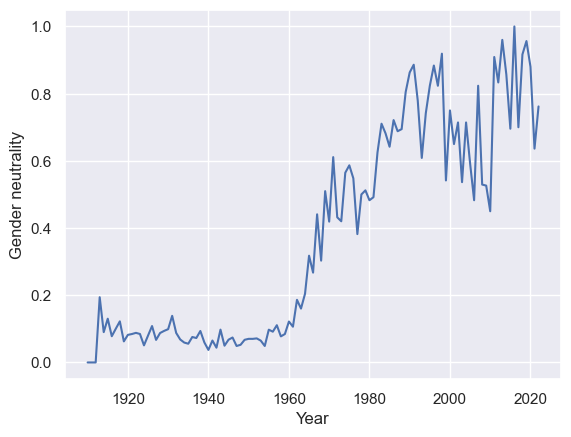

In [16]:
jean = neut_yearly.filter(pl.col('Name') == 'Jean').sort('Year')
sns.lineplot(jean.to_pandas(), x='Year', y='Gender neutrality');

### `group_by().len()` and `count()`

In [17]:
df = pl.DataFrame({'letter':['A', 'A', 'B', 'C', 'C', 'C'],
                   'num':[1, 2, 3, 4, None, 4],
                   'state':[None, 'tx', 'fl', 'hi', None, 'ak']})
df

letter,num,state
str,i64,str
"""A""",1,null
"""A""",2,"""tx"""
"""B""",3,"""fl"""
"""C""",4,"""hi"""
"""C""",null,null
"""C""",4,"""ak"""


`group_by().len()` returns a `DataFrame` with one row per group: the `letter`s that we grouped by, alongside a `len` column giving the number of rows in each group/sub-DataFrame. Missing (`null`) values are counted like any other row.

In [18]:
df.group_by("letter", maintain_order=True).len()

letter,len
str,u32
"""A""",2
"""B""",1
"""C""",3


You might recall `value_counts()` function we talked about last week. What's the difference?

In [19]:
df["letter"].value_counts(sort=True)

letter,count
str,u32
"""C""",3
"""A""",2
"""B""",1


Turns out `value_counts()` reports the same tallies as `group_by().len()`, except that it names its second column `count`, and `sort=True` ranks the letters from most to least common.

Passing `pl.all().count()` to `.agg()` gives you one column per original column, holding the number of non-missing values recorded for that `letter`.

In [20]:
df.group_by("letter", maintain_order=True).agg(pl.all().count())

letter,num,state
str,u32,u32
"""A""",2,1
"""B""",1,1
"""C""",2,2


## Filtering by Group

Another common use for groups is to filter data:

Usage: `df.filter(<aggregate expression>.over(___))`

`.over()` computes an aggregate **within each group** and hands the group's answer back to every row of that group.
- The aggregate collapses each group to a single value, such as `pl.len()` or `pl.col("c").max()`.
- Comparing that value produces `True` or `False` for every row of the group at once.
- `filter` then keeps the rows whose group answered `True` and drops the rest.

For example, we can keep the rows belonging to a `letter` that appears at least twice:

In [21]:
df.filter(pl.len().over("letter") >= 2)

letter,num,state
str,i64,str
"""A""",1,null
"""A""",2,"""tx"""
"""C""",4,"""hi"""
"""C""",null,null
"""C""",4,"""ak"""


### Slido Exercise

Which of the following returns all rows of `babynames` with names that appeared for the first time after 2010?

In [22]:
# babynames.filter(pl.col("Year").min().over("Name") > 2010)

In [23]:
# babynames.filter(pl.col("Year").max().over("Name") > 2010)

In [24]:
# babynames.filter(pl.col("Year").over("Name") > 2010)

In [25]:
# babynames.filter(pl.col("Year").over(["Name", "Year"]) > 2010)

Let's find only the elections years where the maximum vote share `%` is less than 45%.

In [26]:
elections.filter(pl.col("%").max().over("Year") < 45).head(10)

Year,Candidate,Party,Popular vote,Result,%,win_binary
i64,str,str,i64,str,f64,bool
1860,"""Abraham Lincoln""","""Republican""",1855993,"""win""",39.699408,true
1860,"""John Bell""","""Constitutional Union""",590901,"""loss""",12.639283,false
1860,"""John C. Breckinridge""","""Southern Democratic""",848019,"""loss""",18.138998,false
1860,"""Stephen A. Douglas""","""Northern Democratic""",1380202,"""loss""",29.522311,false
1912,"""Eugene V. Debs""","""Socialist""",901551,"""loss""",6.004354,false
1912,"""Eugene W. Chafin""","""Prohibition""",208156,"""loss""",1.386325,false
1912,"""Theodore Roosevelt""","""Progressive""",4122721,"""loss""",27.457433,false
1912,"""William Taft""","""Republican""",3486242,"""loss""",23.218466,false
1912,"""Woodrow Wilson""","""Democratic""",6296284,"""win""",41.933422,true


In [27]:
# Every group_by().agg() hands back a DataFrame: one row per group,
# and one column for each key and each aggregate we asked for.
elections_max_percentage = elections.group_by("Year").agg(pl.col("%").max())
elections_max_percentage

Year,%
i64,f64
1872,55.928594
1868,52.665305
1848,47.309296
1984,59.023326
1920,60.574501
…,…
1836,52.272472
1924,54.329113
1888,48.656799


In [28]:
elections_max_percentage.sort(by="%").head()

Year,%
i64,f64
1860,39.699408
1912,41.933422
1992,43.118485
1968,43.565246
1856,45.30608


### `group_by` Puzzle

Assume that we want to know the best election by each party.

#### Attempt #1

We have to be careful when using aggregation functions. For example, the code below might be misinterpreted to say that Woodrow Wilson successfully ran for election in 2024. Why is this happening?

In [29]:
# Sorting by Party gives us the same ten parties on every run.
elections.group_by("Party").max().sort("Party").head(10)

Party,Year,Candidate,Popular vote,Result,%,win_binary
str,i64,str,i64,str,f64,bool
"""American""",1976,"""Thomas J. Anderson""",873053,"""loss""",21.554001,false
"""American Independent""",1976,"""Lester Maddox""",9901118,"""loss""",13.571218,false
"""Anti-Masonic""",1832,"""William Wirt""",100715,"""loss""",7.821583,false
"""Anti-Monopoly""",1884,"""Benjamin Butler""",134294,"""loss""",1.335838,false
"""Citizens""",1980,"""Barry Commoner""",233052,"""loss""",0.270182,false
"""Communist""",1932,"""William Z. Foster""",103307,"""loss""",0.261069,false
"""Constitution""",2016,"""Michael Peroutka""",203091,"""loss""",0.152398,false
"""Constitutional Union""",1860,"""John Bell""",590901,"""loss""",12.639283,false
"""Democratic""",2024,"""Woodrow Wilson""",81268924,"""win""",61.344703,true


It's generally a good idea to be explicit about which columns to aggregate!

#### Attempt #2

Next, we'll write code that properly returns _the best result by each party_. That is, each row should show the Year, Candidate, Popular Vote, Result, and % for the election in which that party saw its best results (rather than mixing them as in the example above). Here's what the first few rows of the correct output should look like:

<img src="images/parties.png" alt="Image" width="600">

In [30]:
elections_sorted_by_percent = elections.sort("%", descending=True)
elections_sorted_by_percent.head(8)

Year,Candidate,Party,Popular vote,Result,%,win_binary
i64,str,str,i64,str,f64,bool
1964,"""Lyndon Johnson""","""Democratic""",43127041,"""win""",61.344703,true
1936,"""Franklin Roosevelt""","""Democratic""",27752648,"""win""",60.978107,true
1972,"""Richard Nixon""","""Republican""",47168710,"""win""",60.907806,true
1920,"""Warren Harding""","""Republican""",16144093,"""win""",60.574501,true
1984,"""Ronald Reagan""","""Republican""",54455472,"""win""",59.023326,true
1928,"""Herbert Hoover""","""Republican""",21427123,"""win""",58.368524,true
1932,"""Franklin Roosevelt""","""Democratic""",22821277,"""win""",57.672125,true
1956,"""Dwight Eisenhower""","""Republican""",35579180,"""win""",57.650654,true


In [31]:
elections_sorted_by_percent.group_by("Party", maintain_order=True).head(1)

Party,Year,Candidate,Popular vote,Result,%,win_binary
str,i64,str,i64,str,f64,bool
"""Democratic""",1964,"""Lyndon Johnson""",43127041,"""win""",61.344703,true
"""Republican""",1972,"""Richard Nixon""",47168710,"""win""",60.907806,true
"""Democratic-Republican""",1824,"""Andrew Jackson""",151271,"""loss""",57.210122,false
"""National Union""",1864,"""Abraham Lincoln""",2211317,"""win""",54.951512,true
"""Whig""",1840,"""William Henry Harrison""",1275583,"""win""",53.051213,true
…,…,…,…,…,…,…
"""New Alliance""",1988,"""Lenora Fulani""",217221,"""loss""",0.237804,false
"""Taxpayers""",1996,"""Howard Phillips""",184656,"""loss""",0.192045,false
"""States' Rights""",1956,"""T. Coleman Andrews""",107929,"""loss""",0.174883,false


#### Alternative Solutions

You'll soon discover that with `Polars`' rich tool set, there's typically more than one way to get to the same answer. Each approach has different tradeoffs in terms of readability, performance, memory consumption, complexity, and more. It will take some experience for you to develop a sense of which approach is better for each problem, but you should, in general, try to think if you can at least envision a different solution to a given problem, especially if you find your current solution to be particularly convoluted or hard to read.

Here are a couple of other ways of obtaining the same result (in each case, we only show the top part with `head()`). A row's position is the only handle we have on it, so the first approach writes those positions into a column with `with_row_index()` and then uses `arg_max()` to pick out where each party's best election sits (look up both in the documentation!). We then sort by `Party` to match the requested formatting:

In [32]:
best_positions = (
    elections.with_row_index("position")
    .group_by("Party")
    .agg(pl.col("position").get(pl.col("%").arg_max()))
    .sort("Party")
)
best_positions

Party,position
str,u32
"""American""",22
"""American Independent""",115
"""Anti-Masonic""",6
"""Anti-Monopoly""",38
"""Citizens""",127
…,…
"""States' Rights""",110
"""Taxpayers""",147
"""Union""",93


In [33]:
# This is the computational part
best_per_party = elections[best_positions["position"]]

# This sorts by Party to match the formatting above
best_per_party.sort("Party").head()

Year,Candidate,Party,Popular vote,Result,%,win_binary
i64,str,str,i64,str,f64,bool
1856,"""Millard Fillmore""","""American""",873053,"""loss""",21.554001,false
1968,"""George Wallace""","""American Independent""",9901118,"""loss""",13.571218,false
1832,"""William Wirt""","""Anti-Masonic""",100715,"""loss""",7.821583,false
1884,"""Benjamin Butler""","""Anti-Monopoly""",134294,"""loss""",1.335838,false
1980,"""Barry Commoner""","""Citizens""",233052,"""loss""",0.270182,false


And this one doesn't even use `group_by`! This approach instead uses the `unique` method to keep only the last occurrence of each party after having sorted by "%", which is the best performance.  Again, the 2nd line is purely formatting:

In [34]:
best_per_party2 = elections.sort("%").unique(subset=["Party"], keep="last", maintain_order=True)
best_per_party2.sort("Party").head()  # Formatting

Year,Candidate,Party,Popular vote,Result,%,win_binary
i64,str,str,i64,str,f64,bool
1856,"""Millard Fillmore""","""American""",873053,"""loss""",21.554001,false
1968,"""George Wallace""","""American Independent""",9901118,"""loss""",13.571218,false
1832,"""William Wirt""","""Anti-Masonic""",100715,"""loss""",7.821583,false
1884,"""Benjamin Butler""","""Anti-Monopoly""",134294,"""loss""",1.335838,false
1980,"""Barry Commoner""","""Citizens""",233052,"""loss""",0.270182,false


*Challenge:* See if you can find yet another approach that still gives the same answer.

### `GroupBy` Objects

The result of `group_by` is not a `DataFrame` or a list of `DataFrame`s. It is instead a special type called a `GroupBy`.

In [35]:
grouped_by_party = elections.group_by("Party")
type(grouped_by_party)

polars.dataframe.group_by.GroupBy

`GroupBy` objects are structured like dictionaries. In fact, we can build the dictionary with the following code:

In [36]:
groups = dict(grouped_by_party)
sorted(groups.keys())

[('American',),
 ('American Independent',),
 ('Anti-Masonic',),
 ('Anti-Monopoly',),
 ('Citizens',),
 ('Communist',),
 ('Constitution',),
 ('Constitutional Union',),
 ('Democratic',),
 ('Democratic-Republican',),
 ('Dixiecrat',),
 ('Farmer–Labor',),
 ('Free Soil',),
 ('Green',),
 ('Greenback',),
 ('Independent',),
 ('Liberal Republican',),
 ('Libertarian',),
 ('Libertarian Party',),
 ('National Democratic',),
 ('National Republican',),
 ('National Union',),
 ('Natural Law',),
 ('New Alliance',),
 ('Northern Democratic',),
 ('Populist',),
 ('Progressive',),
 ('Prohibition',),
 ('Reform',),
 ('Republican',),
 ('Socialist',),
 ('Southern Democratic',),
 ("States' Rights",),
 ('Taxpayers',),
 ('Union',),
 ('Union Labor',),
 ('Whig',)]

The `key`s of the dictionary are the groups (in this case, `Party`), and the `value`s are the **rows** belonging to that group. Each key arrives as a tuple, since we can group by several columns at once. We can access a particular sub-`DataFrame` by looking up its key:

In [37]:
groups[("Socialist",)]

Year,Candidate,Party,Popular vote,Result,%,win_binary
i64,str,str,i64,str,f64,bool
1904,"""Eugene V. Debs""","""Socialist""",402810,"""loss""",2.985897,false
1908,"""Eugene V. Debs""","""Socialist""",420852,"""loss""",2.850866,false
1912,"""Eugene V. Debs""","""Socialist""",901551,"""loss""",6.004354,false
1916,"""Allan L. Benson""","""Socialist""",590524,"""loss""",3.194193,false
1920,"""Eugene V. Debs""","""Socialist""",913693,"""loss""",3.428282,false
1928,"""Norman Thomas""","""Socialist""",267478,"""loss""",0.728623,false
1932,"""Norman Thomas""","""Socialist""",884885,"""loss""",2.236211,false
1936,"""Norman Thomas""","""Socialist""",187910,"""loss""",0.412876,false
1940,"""Norman Thomas""","""Socialist""",116599,"""loss""",0.234237,false


---

## Pivot Tables

### `group_by` with multiple columns

We want to build a table showing the total number of babies born of each sex in each year. One way is to `group_by` using both columns of interest:

In [38]:
babynames.group_by(["Year", "Sex"]).agg(pl.col("Count").sum()).sort(["Year", "Sex"])

Year,Sex,Count
i64,str,i64
1910,"""F""",5950
1910,"""M""",3213
1911,"""F""",6602
1911,"""M""",3381
1912,"""F""",9804
…,…,…
2020,"""M""",189119
2021,"""F""",173913
2021,"""M""",188669


### `pivot`

In [39]:
babynames.head()

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Mary""",295
"""CA""","""F""",1910,"""Helen""",239
"""CA""","""F""",1910,"""Dorothy""",220
"""CA""","""F""",1910,"""Margaret""",163
"""CA""","""F""",1910,"""Frances""",134


In [40]:
babynames.pivot(
    index="Year",
    on="Sex",
    values="Count",
    aggregate_function="sum")

Year,F,M
i64,i64,i64
1910,5950,3213
1911,6602,3381
1912,9804,8142
1913,11860,10234
1914,13815,13111
…,…,…
2018,189208,206228
2019,184228,202768
2020,173763,189119


### `pivot` with Multiple values

When `values` names more than one column, each output column is labelled `{value}_{sex}`.

In [41]:
babynames.pivot(
    index="Year",
    on="Sex",
    values=["Count", "Name"],
    aggregate_function="max")

Year,Count_F,Count_M,Name_F,Name_M
i64,i64,i64,str,str
1910,295,237,"""Yvonne""","""William"""
1911,390,214,"""Zelma""","""Willis"""
1912,534,501,"""Yvonne""","""Woodrow"""
1913,584,614,"""Zelma""","""Yoshio"""
1914,773,769,"""Zelma""","""Yoshio"""
…,…,…,…,…
2018,2751,2572,"""Zyra""","""Zyon"""
2019,2608,2681,"""Zyra""","""Zyon"""
2020,2353,2630,"""Zyrah""","""Zyon"""


---

## Joining Tables

What if we want to know the popularity of presidential candidates' first names in California in 2022? What can we do?

In [42]:
elections.head(10)

Year,Candidate,Party,Popular vote,Result,%,win_binary
i64,str,str,i64,str,f64,bool
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122,false
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878,true
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927,true
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073,false
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789,true
1832,"""Henry Clay""","""National Republican""",484205,"""loss""",37.603628,false
1832,"""William Wirt""","""Anti-Masonic""",100715,"""loss""",7.821583,false
1836,"""Hugh Lawson White""","""Whig""",146109,"""loss""",10.005985,false
1836,"""Martin Van Buren""","""Democratic""",763291,"""win""",52.272472,true


In [43]:
babynames_2022 = babynames.filter(pl.col("Year") == 2022)
babynames_2022.head(10)

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",2022,"""Olivia""",2178
"""CA""","""F""",2022,"""Emma""",2080
"""CA""","""F""",2022,"""Camila""",2046
"""CA""","""F""",2022,"""Mia""",1882
"""CA""","""F""",2022,"""Sophia""",1762
"""CA""","""F""",2022,"""Isabella""",1733
"""CA""","""F""",2022,"""Luna""",1516
"""CA""","""F""",2022,"""Sofia""",1307
"""CA""","""F""",2022,"""Amelia""",1289


In [44]:
elections = elections.with_columns(
    pl.col("Candidate").str.split(" ").list.get(0).alias("First Name")
)
elections

Year,Candidate,Party,Popular vote,Result,%,win_binary,First Name
i64,str,str,i64,str,f64,bool,str
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122,false,"""Andrew"""
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878,true,"""John"""
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927,true,"""Andrew"""
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073,false,"""John"""
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789,true,"""Andrew"""
…,…,…,…,…,…,…,…
2024,"""Donald Trump""","""Republican""",77303568,"""win""",49.808629,true,"""Donald"""
2024,"""Kamala Harris""","""Democratic""",75019230,"""loss""",48.336772,false,"""Kamala"""
2024,"""Jill Stein""","""Green""",861155,"""loss""",0.554864,false,"""Jill"""


As in Data 8, this operation is called `join`. The left table calls the method and the right table is its first argument.

In [45]:
display(elections.head())
display(babynames_2022.head())

merged = elections.join(
    babynames_2022,
    left_on="First Name", right_on="Name",
    maintain_order="left"
)
merged

Year,Candidate,Party,Popular vote,Result,%,win_binary,First Name
i64,str,str,i64,str,f64,bool,str
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122,false,"""Andrew"""
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878,true,"""John"""
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927,true,"""Andrew"""
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073,false,"""John"""
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789,true,"""Andrew"""


State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",2022,"""Olivia""",2178
"""CA""","""F""",2022,"""Emma""",2080
"""CA""","""F""",2022,"""Camila""",2046
"""CA""","""F""",2022,"""Mia""",1882
"""CA""","""F""",2022,"""Sophia""",1762


Year,Candidate,Party,Popular vote,Result,%,win_binary,First Name,State,Sex,Year_right,Count
i64,str,str,i64,str,f64,bool,str,str,str,i64,i64
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122,false,"""Andrew""","""CA""","""M""",2022,741
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878,true,"""John""","""CA""","""M""",2022,490
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927,true,"""Andrew""","""CA""","""M""",2022,741
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073,false,"""John""","""CA""","""M""",2022,490
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789,true,"""Andrew""","""CA""","""M""",2022,741
…,…,…,…,…,…,…,…,…,…,…,…
2020,"""Howard Hawkins""","""Green""",405035,"""loss""",0.255731,false,"""Howard""","""CA""","""M""",2022,18
2024,"""Donald Trump""","""Republican""",77303568,"""win""",49.808629,true,"""Donald""","""CA""","""M""",2022,33
2024,"""Robert Kennedy""","""Independent""",756383,"""loss""",0.487357,false,"""Robert""","""CA""","""M""",2022,404


In [46]:
merged.sort("Count", descending=True)

Year,Candidate,Party,Popular vote,Result,%,win_binary,First Name,State,Sex,Year_right,Count
i64,str,str,i64,str,f64,bool,str,str,str,i64,i64
1884,"""Benjamin Butler""","""Anti-Monopoly""",134294,"""loss""",1.335838,false,"""Benjamin""","""CA""","""M""",2022,1524
1888,"""Benjamin Harrison""","""Republican""",5443633,"""win""",47.858041,true,"""Benjamin""","""CA""","""M""",2022,1524
1892,"""Benjamin Harrison""","""Republican""",5176108,"""loss""",42.984101,false,"""Benjamin""","""CA""","""M""",2022,1524
1844,"""James Polk""","""Democratic""",1339570,"""win""",50.749477,true,"""James""","""CA""","""M""",2022,1086
1856,"""James Buchanan""","""Democratic""",1835140,"""win""",45.30608,true,"""James""","""CA""","""M""",2022,1086
…,…,…,…,…,…,…,…,…,…,…,…
1912,"""Woodrow Wilson""","""Democratic""",6296284,"""win""",41.933422,true,"""Woodrow""","""CA""","""M""",2022,6
1916,"""Woodrow Wilson""","""Democratic""",9126868,"""win""",49.367987,true,"""Woodrow""","""CA""","""M""",2022,6
1964,"""Lyndon Johnson""","""Democratic""",43127041,"""win""",61.344703,true,"""Lyndon""","""CA""","""M""",2022,6


### `join`ing back the results of a `group_by` operation

In [47]:
neutral = babynames.join(neut_yearly, on=["Name", "Year"], maintain_order="left")
neutral

State,Sex,Year,Name,Count,Gender neutrality
str,str,i64,str,i64,f64
"""CA""","""F""",1910,"""Mary""",295,0.0
"""CA""","""F""",1910,"""Helen""",239,0.0
"""CA""","""F""",1910,"""Dorothy""",220,0.0
"""CA""","""F""",1910,"""Margaret""",163,0.0
"""CA""","""F""",1910,"""Frances""",134,0.0
…,…,…,…,…,…
"""CA""","""M""",2022,"""Zayvier""",5,0.0
"""CA""","""M""",2022,"""Zia""",5,0.27027
"""CA""","""M""",2022,"""Zora""",5,0.294118


In [48]:
common_neutrals = neutral.filter(
    (pl.col('Count') > 100) & (pl.col('Gender neutrality') > 0)
)

In [49]:
(
    common_neutrals.sort('Gender neutrality')
    .group_by('Year').tail(1)
    .sort('Year')
    .tail(30)
)

Year,State,Sex,Name,Count,Gender neutrality
i64,str,str,str,i64,f64
1993,"""CA""","""F""","""Robin""",102,0.785714
1994,"""CA""","""M""","""Jessie""",186,0.882883
1995,"""CA""","""M""","""Casey""",249,0.878378
1996,"""CA""","""M""","""Casey""",225,0.920863
1997,"""CA""","""M""","""Casey""",201,0.870787
…,…,…,…,…,…
2018,"""CA""","""M""","""Charlie""",171,0.994118
2019,"""CA""","""M""","""Charlie""",193,0.992288
2020,"""CA""","""M""","""Alexis""",148,0.927536


### Case Study: Name "Popularity"

In this exercise, let's find the name with sex "F" that has dropped most in popularity since its peak usage in California. We'll start by filtering `babynames` to only include names corresponding to sex "F".

In [50]:
f_babynames = babynames.filter(pl.col("Sex") == "F")
f_babynames

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Mary""",295
"""CA""","""F""",1910,"""Helen""",239
"""CA""","""F""",1910,"""Dorothy""",220
"""CA""","""F""",1910,"""Margaret""",163
"""CA""","""F""",1910,"""Frances""",134
…,…,…,…,…
"""CA""","""F""",2022,"""Zemira""",5
"""CA""","""F""",2022,"""Ziggy""",5
"""CA""","""F""",2022,"""Zimal""",5


To build our intuition on how to answer our research question, let's visualize the prevalence of the name "Jennifer" over time.

In [51]:
jenn_entries = f_babynames.filter(pl.col("Name") == "Jennifer")
jenn_entries

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1934,"""Jennifer""",5
"""CA""","""F""",1938,"""Jennifer""",5
"""CA""","""F""",1939,"""Jennifer""",6
"""CA""","""F""",1940,"""Jennifer""",13
"""CA""","""F""",1941,"""Jennifer""",24
…,…,…,…,…
"""CA""","""F""",2018,"""Jennifer""",167
"""CA""","""F""",2019,"""Jennifer""",145
"""CA""","""F""",2020,"""Jennifer""",141


In [52]:
# We'll talk about how to generate plots in a later lecture
fig = px.line(jenn_entries, x="Year", y="Count")

fig.update_layout(font_size = 18,
                  autosize=False,
                  width=1000,
                  height=400)

We'll need a mathematical definition for the change in popularity of a name in California.

Define the metric "Ratio to Peak" (RTP). We'll calculate this as the count of the name in 2022 (the most recent year for which we have data) divided by the largest count of this name in *any* year.

A demo calculation for Jennifer:

In [53]:
# Construct a Series containing our Jennifer count data
jenn_counts_ser = jenn_entries["Count"]

In [54]:
# In the year with the highest Jennifer count, 6065 Jennifers were born
max_jenn = jenn_counts_ser.max()
max_jenn

6065

In [55]:
# Remember that we sorted f_babynames by "Year".
# This means that grabbing the final entry gives us the most recent count of Jennifers: 114
# In 2022, the most recent year for which we have data, 114 Jennifers were born
latest_jenn = jenn_counts_ser[-1]
latest_jenn

114

In [56]:
# Compute the RTP
latest_jenn / max_jenn

0.018796372629843364

We can also write a function that produces the `ratio_to_peak`for a given `Series`. This will allow us to use `.group_by` to speed up our computation for all names in the dataset.

In [57]:
def ratio_to_peak(series):
    """
    Compute the RTP for a Series containing the counts per year for a single name (year column sorted ascendingly).
    """
    return series.last() / series.max()

In [58]:
# Then, find the RTP
ratio_to_peak(jenn_counts_ser)

0.018796372629843364

Now, let's use `.group_by` to compute the RTPs for *all* names in the dataset.

Naming the two columns of interest inside `.agg()` runs the aggregation on exactly the numeric data it makes sense for. Handing it the whole table would ask it to divide "CA" by a number.

In [59]:
rtp_table = f_babynames.group_by("Name").agg(
    pl.col("Year", "Count").map_batches(ratio_to_peak, returns_scalar=True)
)
rtp_table

Name,Year,Count
str,f64,f64
"""Acelynn""",1.0,0.5
"""Lianna""",1.0,0.673913
"""Tahira""",1.0,1.0
"""Edna""",1.0,0.031447
"""Simrat""",1.0,0.714286
…,…,…
"""Yamilette""",1.0,0.857143
"""Renita""",1.0,0.2
"""Polina""",1.0,0.625


This is the `Polars` equivalent of `.group` from [Data 8](http://data8.org/datascience/_autosummary/datascience.tables.Table.group.html). If we wanted to achieve this same result using the `datascience` library, we would write:

`f_babynames.group("Name", ratio_to_peak)`

In this exercise, let's find the name with sex "F" that has dropped most in popularity since its peak usage in California. We'll start by filtering `babynames` to only include names corresponding to sex "F".

In [60]:
f_babynames = babynames.filter(pl.col("Sex") == "F")
f_babynames

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Mary""",295
"""CA""","""F""",1910,"""Helen""",239
"""CA""","""F""",1910,"""Dorothy""",220
"""CA""","""F""",1910,"""Margaret""",163
"""CA""","""F""",1910,"""Frances""",134
…,…,…,…,…
"""CA""","""F""",2022,"""Zemira""",5
"""CA""","""F""",2022,"""Ziggy""",5
"""CA""","""F""",2022,"""Zimal""",5


To build our intuition on how to answer our research question, let's visualize the prevalence of the name "Jennifer" over time.

In [61]:
jenn_entries = f_babynames.filter(pl.col("Name") == "Jennifer")
jenn_entries

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1934,"""Jennifer""",5
"""CA""","""F""",1938,"""Jennifer""",5
"""CA""","""F""",1939,"""Jennifer""",6
"""CA""","""F""",1940,"""Jennifer""",13
"""CA""","""F""",1941,"""Jennifer""",24
…,…,…,…,…
"""CA""","""F""",2018,"""Jennifer""",167
"""CA""","""F""",2019,"""Jennifer""",145
"""CA""","""F""",2020,"""Jennifer""",141


In [62]:
# We'll talk about how to generate plots in a later lecture
fig = px.line(jenn_entries, x="Year", y="Count")

fig.update_layout(font_size = 18,
                  autosize=False,
                  width=1000,
                  height=400)

We'll need a mathematical definition for the change in popularity of a name in California.

Define the metric "Ratio to Peak" (RTP). We'll calculate this as the count of the name in 2022 (the most recent year for which we have data) divided by the largest count of this name in *any* year.

A demo calculation for Jennifer:

In [63]:
# Construct a Series containing our Jennifer count data
jenn_counts_ser = jenn_entries["Count"]

In [64]:
# In the year with the highest Jennifer count, 6065 Jennifers were born
max_jenn = jenn_counts_ser.max()
max_jenn

6065

In [65]:
# Remember that we sorted f_babynames by "Year".
# This means that grabbing the final entry gives us the most recent count of Jennifers: 114
# In 2022, the most recent year for which we have data, 114 Jennifers were born
latest_jenn = jenn_counts_ser[-1]
latest_jenn

114

In [66]:
# Compute the RTP
latest_jenn / max_jenn

0.018796372629843364

We can also write a function that produces the `ratio_to_peak`for a given `Series`. This will allow us to use `.group_by` to speed up our computation for all names in the dataset.

In [67]:
def ratio_to_peak(series):
    """
    Compute the RTP for a Series containing the counts per year for a single name (year column sorted ascendingly).
    """
    return series.last() / series.max()

In [68]:
# Then, find the RTP
ratio_to_peak(jenn_counts_ser)

0.018796372629843364

Now, let's use `.group_by` to compute the RTPs for *all* names in the dataset.

Naming the two columns of interest inside `.agg()` runs the aggregation on exactly the numeric data it makes sense for. Handing it the whole table would ask it to divide "CA" by a number.

In [69]:
rtp_table = f_babynames.group_by("Name").agg(
    pl.col("Year", "Count").map_batches(ratio_to_peak, returns_scalar=True)
)
rtp_table

Name,Year,Count
str,f64,f64
"""Ester""",1.0,0.5
"""Arianna""",1.0,0.376552
"""Abrar""",1.0,1.0
"""Jeani""",1.0,1.0
"""Scarlette""",1.0,0.586667
…,…,…
"""Brent""",1.0,1.0
"""Zahira""",1.0,0.625
"""Sora""",1.0,0.928571


This is the `Polars` equivalent of `.group` from [Data 8](http://data8.org/datascience/_autosummary/datascience.tables.Table.group.html). If we wanted to achieve this same result using the `datascience` library, we would write:

`f_babynames.group("Name", ratio_to_peak)`

### Slido Exercise

Is there a row where `Year` is not equal to 1? Recall that `babynames` is sorted ascending by year.

In [70]:
f_babynames

State,Sex,Year,Name,Count
str,str,i64,str,i64
"""CA""","""F""",1910,"""Mary""",295
"""CA""","""F""",1910,"""Helen""",239
"""CA""","""F""",1910,"""Dorothy""",220
"""CA""","""F""",1910,"""Margaret""",163
"""CA""","""F""",1910,"""Frances""",134
…,…,…,…,…
"""CA""","""F""",2022,"""Zemira""",5
"""CA""","""F""",2022,"""Ziggy""",5
"""CA""","""F""",2022,"""Zimal""",5


In [71]:
# Unique values in the Year column
rtp_table["Year"].unique()

Year
f64
1.0


A hint: If we randomly shuffle the dataset, we see values of `Year` other than 1.
- The maximum year for each name is no longer guaranteed to be the last-appearing year for each name! So, the ratio is no longer 1.

In [72]:
(
    f_babynames.sample(fraction=1, with_replacement=False, shuffle=True)
    .group_by("Name")
    .agg(pl.col("Year", "Count").map_batches(ratio_to_peak, returns_scalar=True))
)

Name,Year,Count
str,f64,f64
"""Jeneen""",0.995951,0.555556
"""Vonetta""",0.996971,0.857143
"""Neveah""",0.991592,0.652174
"""Taura""",0.999492,0.714286
"""Claryssa""",0.997506,1.0
…,…,…
"""Dylann""",0.997525,0.5
"""Talyah""",1.0,1.0
"""Frania""",1.0,1.0


In [73]:
# Dropping the "Year" column
rtp_table = rtp_table.drop("Year")
rtp_table

Name,Count
str,f64
"""Ester""",0.5
"""Arianna""",0.376552
"""Abrar""",1.0
"""Jeani""",1.0
"""Scarlette""",0.586667
…,…
"""Brent""",1.0
"""Zahira""",0.625
"""Sora""",0.928571


In [74]:
# Rename "Count" to "Count RTP" for clarity
rtp_table = rtp_table.rename({"Count":"Count RTP"})
rtp_table

Name,Count RTP
str,f64
"""Ester""",0.5
"""Arianna""",0.376552
"""Abrar""",1.0
"""Jeani""",1.0
"""Scarlette""",0.586667
…,…
"""Brent""",1.0
"""Zahira""",0.625
"""Sora""",0.928571


In [75]:
# What name has fallen the most in popularity?
rtp_table.sort("Count RTP", descending=False)

Name,Count RTP
str,f64
"""Debra""",0.00126
"""Debbie""",0.002815
"""Carol""",0.00318
"""Tammy""",0.003249
"""Susan""",0.003305
…,…
"""Zaylie""",1.0
"""Roshell""",1.0
"""Vida""",1.0


We can visualize the decrease in the popularity of the name "Debra:"

In [76]:
# Don't worry about the * in the function definition!
# Focus on the plot.
def plot_name(*names):
    fig = px.line(f_babynames.filter(pl.col("Name").is_in(names)),
                  x="Year", y="Count", color="Name",
                  title=f"Popularity for: {names}")
    fig.update_layout(font_size=18,
                  autosize=False,
                  width=1000,
                  height=400)
    return fig

plot_name("Debra")

In [77]:
# Find the 10 names that have decreased the most in popularity.
# The names are an ordinary column of rtp_table, so we can read them straight out.
top10 = rtp_table.sort("Count RTP").head(10)["Name"].to_list()
top10

['Debra',
 'Debbie',
 'Carol',
 'Tammy',
 'Susan',
 'Cheryl',
 'Shannon',
 'Tina',
 'Michele',
 'Terri']

In [78]:
plot_name(*top10)

For fun, try plotting your name or your friends' names.